###
<h2 style="margin-bottom: 0;">Hotel Reviews:</h2>
<h1 style="margin-top: 5px; color: #003580; font-size: 45px; font-weight: bold;">Booking.com</h1>

####
**Import Librerie**

**Pandas:** Manipolazione e analisi dei Dati  
**NumPy:** Calcolo scientifico e matematico  
**Matplotlib:** Creazione di grafici e visualizzazione dati

In [1]:
import pandas as pandas
import numpy as numpy
import matplotlib
import matplotlib.pyplot as plt

print('Pandas:', pandas.__version__)
print('NumPy:', numpy.__version__)
print('Matplotlib:', matplotlib.__version__)

Pandas: 3.0.3
NumPy: 2.4.6
Matplotlib: 3.11.0


Configurazione stile grafici

Impostazione di uno stile coerente per tutti gli 8 grafici richiesti.<br>
Per garantire titoli, etichette e layout puliti (punto 4.5 delle istruzioni).

In [2]:
# Verifica degli stili "seaborn" disponibili
import matplotlib.pyplot as plt
print([s for s in plt.style.available if 'seaborn' in s])



['seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid']


In [3]:
# Configurazione globale dello stile grafico
plt.style.use('seaborn-v0_8-whitegrid')

# Impostazioni per rendere i font e le figure proporzionate
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Verifica configurazione applicata
print("Stile applicato: seaborn-v0_8-whitegrid")
print("Figsize di default:", plt.rcParams['figure.figsize'])
print("Dimensione titolo:", plt.rcParams['axes.titlesize'])
print("Dimensione etichette:", plt.rcParams['axes.labelsize'])

Stile applicato: seaborn-v0_8-whitegrid
Figsize di default: [10.0, 6.0]
Dimensione titolo: 14.0
Dimensione etichette: 12.0


## **4.4 Analisi con Pandas**

###
**4.4.1 Importare da SQL o usare dataframe pulito**



Caricamento del dataframe pulito

Caricamento `DATASET.csv`,<br>il file prodotto dal notebook 01,<br>già pulito e completo delle variabili derivate (City, Score_Category, Total_Review_Length, ecc.).

In [4]:
df = pandas.read_csv("dataset.csv", parse_dates=["Review_Date"])
print("Shape:", df.shape)
df.head()

Shape: (515212, 22)


,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,...,Reviewer_Score,Tags,days_since_review,lat,lng,Review_Year,Review_Month,Total_Review_Length,Score_Category,City
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam N...,194,2017-08-03,7.7,Hotel Arena,Russia,I am so angry that i made this post available...,397,1403,Only the park outside of the hotel was beauti...,...,2.9,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0,52.360576,4.915968,2017,8,408,Basso (0-5),Amsterdam
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam N...,194,2017-08-03,7.7,Hotel Arena,Ireland,No Negative,0,1403,No real complaints the hotel was great great ...,...,7.5,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0,52.360576,4.915968,2017,8,105,Buono (7-9),Amsterdam
2,s Gravesandestraat 55 Oost 1092 AA Amsterdam N...,194,2017-07-31,7.7,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficul...,42,1403,Location was good and staff were ok It is cut...,...,7.1,"[' Leisure trip ', ' Family with young childre...",3,52.360576,4.915968,2017,7,63,Buono (7-9),Amsterdam
3,s Gravesandestraat 55 Oost 1092 AA Amsterdam N...,194,2017-07-31,7.7,Hotel Arena,United Kingdom,My room was dirty and I was afraid to walk ba...,210,1403,Great location in nice surroundings the bar a...,...,3.8,"[' Leisure trip ', ' Solo traveler ', ' Duplex...",3,52.360576,4.915968,2017,7,236,Basso (0-5),Amsterdam
4,s Gravesandestraat 55 Oost 1092 AA Amsterdam N...,194,2017-07-24,7.7,Hotel Arena,New Zealand,You When I booked with your company on line y...,140,1403,Amazing location and building Romantic setting,...,6.7,"[' Leisure trip ', ' Couple ', ' Suite ', ' St...",10,52.360576,4.915968,2017,7,148,Medio (5-7),Amsterdam


###
**4.4.2 Riprodurre analisi SQL principali**<br>
(group by mensile, ranking nazionalità, distribuzione città)



Si ripete con pandas le stesse 3 analisi chiave già fatte in SQL<br>
`analysis_queries.sql`

####
4.4.2.1 Group by mensile

Raggruppamento mensile delle recensioni

In [5]:
# 1. Recensioni nel Tempo: Andamento recensioni mese e anno (Riproduzione Query SQL 4.3.1.1)
print("--- 1. RAGGRUPPAMENTO DELLE RECENZIONI PER MESE E ANNO ---")
conteggio_mensile = df.groupby(['Review_Year', 'Review_Month']).size().reset_index(name='Numero_Recensioni')

nomi_mesi = {
    1: 'Gennaio', 2: 'Febbraio', 3: 'Marzo', 4: 'Aprile', 
    5: 'Maggio', 6: 'Giugno', 7: 'Luglio', 8: 'Agosto', 
    9: 'Settembre', 10: 'Ottobre', 11: 'Novembre', 12: 'Dicembre'
}
conteggio_mensile['Nome_Mese'] = conteggio_mensile['Review_Month'].map(nomi_mesi)

# Ordinamento esplicito per garantire la sequenza cronologica corretta
conteggio_mensile = conteggio_mensile.sort_values(by=['Review_Year', 'Review_Month'])

conteggio_mensile = conteggio_mensile[['Review_Month', 'Nome_Mese', 'Review_Year', 'Numero_Recensioni']]
print(conteggio_mensile.to_string(index=False))

--- 1. RAGGRUPPAMENTO DELLE RECENZIONI PER MESE E ANNO ---
 Review_Month Nome_Mese  Review_Year  Numero_Recensioni
            8    Agosto         2015              19287
            9 Settembre         2015              19689
           10   Ottobre         2015              19449
           11  Novembre         2015              18039
           12  Dicembre         2015              17914
            1   Gennaio         2016              19496
            2  Febbraio         2016              18836
            3     Marzo         2016              20722
            4    Aprile         2016              21471
            5    Maggio         2016              23055
            6    Giugno         2016              20920
            7    Luglio         2016              25865
            8    Agosto         2016              27252
            9 Settembre         2016              22652
           10   Ottobre         2016              24324
           11  Novembre         2016         

####
4.4.2.2 Ranking nazionalità

Ranking nazionalità per numero recensioni e score medio

In [6]:
# 2. Ranking delle Top 10 Nazionalità per numero recensioni e score medio (Riproduzione Query SQL 4.3.2.1)
print("--- 2. TOP 10 NAZIONALITÀ PER VOLUME DI RECENSIONI E SCORE MEDIO ---")

# Aggregazione: calcolo del conteggio e della media dello score per ogni nazionalità
ranking_nazionalita = df.groupby('Reviewer_Nationality').agg(
    Numero_Recensioni=('Reviewer_Score', 'count'),
    Score_Medio=('Reviewer_Score', 'mean')
).reset_index()

# Ordinamento decrescente per numero di recensioni e selezione delle prime 10 posizioni
top_10_nazionalita = ranking_nazionalita.sort_values(by='Numero_Recensioni', ascending=False).head(10)
# Formattazione dello score a 2 decimali per pulizia visiva
top_10_nazionalita['Score_Medio'] = top_10_nazionalita['Score_Medio'].round(2)

print(top_10_nazionalita.to_string(index=False))

--- 2. TOP 10 NAZIONALITÀ PER VOLUME DI RECENSIONI E SCORE MEDIO ---
    Reviewer_Nationality  Numero_Recensioni  Score_Medio
          United Kingdom             245110         8.49
United States of America              35349         8.79
               Australia              21648         8.59
                 Ireland              14814         8.46
    United Arab Emirates              10229         7.88
            Saudi Arabia               8940         7.88
             Netherlands               8757         8.13
             Switzerland               8669         8.16
                 Germany               7929         8.13
                  Canada               7883         8.55


####
4.4.2.3 Distribuzione Città

Distribuzione recensioni per città

In [7]:
# Distribuzione delle recensioni per città (Riproduzione Query SQL 4.3.4.1)
print("--- 3. DISTRIBUZIONE DELLE RECENSIONI PER CITTÀ ---")

# Aggregazione: conteggio delle recensioni per ciascuna città
distribuzione_citta = df.groupby('City').size().reset_index(name='Numero_Recensioni')

# Ordinamento decrescente per volume di recensioni
distribuzione_citta = distribuzione_citta.sort_values(by='Numero_Recensioni', ascending=False)

print(distribuzione_citta.to_string(index=False))

--- 3. DISTRIBUZIONE DELLE RECENSIONI PER CITTÀ ---
     City  Numero_Recensioni
   London             262298
Barcelona              60149
    Paris              59413
Amsterdam              57211
   Vienna              38937
    Milan              37204


### 
**4.4.3 Confronto risultati SQL vs pandas**

In [8]:
print("=== CONFRONTO SQL vs PANDAS ===\n")

print("1. Recensioni mensili (agosto 2015):")
print(f"   SQL:    19287")
print(f"   Pandas: {conteggio_mensile[(conteggio_mensile['Review_Year']==2015) & (conteggio_mensile['Review_Month']==8)]['Numero_Recensioni'].values[0]}")

print("\n2. Top nazionalità (United Kingdom):")
print(f"   SQL:    245110 recensioni, score medio 8.49")
print(f"   Pandas: {top_10_nazionalita.iloc[0]['Numero_Recensioni']} recensioni, score medio {top_10_nazionalita.iloc[0]['Score_Medio']}")

print("\n3. Distribuzione città (London):")
print(f"   SQL:    262298 recensioni")
print(f"   Pandas: {distribuzione_citta.iloc[0]['Numero_Recensioni']} recensioni")



=== CONFRONTO SQL vs PANDAS ===

1. Recensioni mensili (agosto 2015):
   SQL:    19287
   Pandas: 19287

2. Top nazionalità (United Kingdom):
   SQL:    245110 recensioni, score medio 8.49
   Pandas: 245110 recensioni, score medio 8.49

3. Distribuzione città (London):
   SQL:    262298 recensioni
   Pandas: 262298 recensioni


Il confronto diretto tra le metriche estratte tramite le query nel database relazionale (punto 4.3) e le aggregazioni logiche effettuate in Pandas (punto 4.4.2) evidenzia una **perfetta convergenza dei dati** su tutte e tre le analisi replicate:

1. **Andamento Temporale (Mese/Anno):** Il conteggio record rispecchia esattamente la distribuzione cronologica (es. 19.287 recensioni ad Agosto 2015, fino alla chiusura parziale di Agosto 2017 con 4.076).
2. **Ranking Nazionalità:** Le Top 10 nazionalità per volume mostrano gli stessi identici record aggregati, confermando l'assoluta predominanza del mercato del Regno Unito (245.110 recensioni) e la coerenza dei punteggi medi calcolati.
3. **Distribuzione per Città:** I volumi riscontrati sulle 6 città chiave (da Londra con 262.298 record fino a Milano con 37.204) collimano al singolo record.

**Conclusione tecnica:** Questo test di coerenza incrociata esclude la presenza di anomalie di caricamento, perdite di righe (data loss) o disallineamenti logici durante i passaggi di pipeline tra SQL e Pandas. Il dataset caricato in memoria è validato e pronto per le fasi di Feature Engineering e Visualizzazione.

### 
**4.4.4 Feature engineering: sentiment base da word counts, cluster città per
score**

####
4.4.4.1 Feature engineering: sentiment base da word counts



In questa sezione viene calcolata una metrica di sentiment nativa basata sui conteggi di parole positive e negative presenti nel dataset.

**Scelta metodologica:** Invece di calcolare una semplice differenza assoluta (che legherebbe lo score finale unicamente alla lunghezza della recensione, falsando il confronto), si è scelto di implementare uno **score normalizzato** (differenza divisa per il conteggio totale delle parole). Questo accorgimento restituisce un indicatore pesato e comparabile, compreso tra -1 e +1.
Inoltre, per evitare di classificare in modo binario e distorto le recensioni perfettamente bilanciate (Score = 0) o quelle del tutto prive di testo, è stata introdotta un'etichetta categorica tripartita (`Positivo`, `Negativo`, `Neutro`).

In [9]:
# 1. Calcolo del Sentiment_Score normalizzato (da -1 a 1) usando 'numpy'
parole_totali = df['Review_Total_Positive_Word_Counts'] + df['Review_Total_Negative_Word_Counts']

df['Sentiment_Score'] = numpy.where(
    parole_totali > 0,
    (df['Review_Total_Positive_Word_Counts'] - df['Review_Total_Negative_Word_Counts']) / parole_totali,
    0.0
)

# 2. Funzione per la creazione della variabile categorica Sentiment_Label (3 stati)
def definisci_label_sentiment(score):
    if score > 0:
        return 'Positivo'
    elif score < 0:
        return 'Negativo'
    else:
        return 'Neutro'

df['Sentiment_Label'] = df['Sentiment_Score'].apply(definisci_label_sentiment)

# 3. Verifica dei conteggi delle etichette generate e anteprima
print("Distribuzione del Sentiment calcolato:")
print(df['Sentiment_Label'].value_counts())
print("\nAnteprima delle colonne generate:")
print(df[['Review_Total_Positive_Word_Counts', 'Review_Total_Negative_Word_Counts', 'Sentiment_Score', 'Sentiment_Label']].head())

Distribuzione del Sentiment calcolato:
Sentiment_Label
Positivo    271316
Negativo    228053
Neutro       15843
Name: count, dtype: int64

Anteprima delle colonne generate:
   Review_Total_Positive_Word_Counts  Review_Total_Negative_Word_Counts  \
0                                 11                                397   
1                                105                                  0   
2                                 21                                 42   
3                                 26                                210   
4                                  8                                140   

   Sentiment_Score Sentiment_Label  
0        -0.946078        Negativo  
1         1.000000        Positivo  
2        -0.333333        Negativo  
3        -0.779661        Negativo  
4        -0.891892        Negativo  


**Insight Analitico sul Comportamento dei Recensori:**<br>
L'output del sentiment testuale fa emergere una dinamica comportamentale molto interessante.<br>Nonostante il dataset presenti un forte bias positivo nei punteggi numerici espliciti<br>(`Reviewer_Score` con mediana molto alta, intorno all'8.8), il sentiment calcolato sull'effettivo volume di parole scritte risulta molto più bilanciato (circa 271.000 recensioni positive contro 228.000 negative).

Questo scostamento suggerisce che gli utenti tendono ad assegnare voti finali generosi, ma utilizzano lo spazio testuale per descrivere minuziosamente le criticità, impiegando frequentemente un maggior numero di parole per le lamentele rispetto ai complimenti.<br>Si tratta di una caratteristica fondamentale da tenere in considerazione per la corretta interpretazione del dato.

####
4.4.4.2 Feature engineering: Cluster città per score

In [10]:
# 1. Calcolo del punteggio medio ricevuto da ogni città
city_mean_scores = df.groupby('City')['Reviewer_Score'].mean().reset_index(name='City_Mean_Score')

# 2. Controllo di quante righe ci sono prima di unire i dati
print(f"Righe prima del merge: {len(df)}")

# 3. Divisione delle città in 3 gruppi in base al punteggio: Bassa, Media, Alta
#    (qcut divide automaticamente in modo che ogni gruppo abbia lo stesso numero di città)
city_mean_scores['City_Score_Cluster'] = pandas.qcut(
    city_mean_scores['City_Mean_Score'],
    q=3,
    labels=['Fascia Bassa', 'Fascia Media', 'Fascia Alta']
)

# 4. Uniamo il gruppo (fascia) a ogni singola recensione, in base alla città
df_prev = df.copy()  # Salviamo una copia di sicurezza
df = df.merge(city_mean_scores[['City', 'City_Score_Cluster']], on='City', how='left')

# 5. Si controlla che l'unione sia andata bene: stesso numero di righe di prima e nessuna riga senza fascia assegnata
print(f"Righe dopo il merge: {len(df)}")
print(f"Numero di valori nulli creati nel merge: {df['City_Score_Cluster'].isna().sum()}")

# 6. Si controlla che ogni fascia contenga davvero 2 città (avendone 6 in totale, divise in 3 gruppi)
distribuzione_fasce_citta = city_mean_scores['City_Score_Cluster'].value_counts().sort_index()
print("\n--- DISTRIBUZIONE CITTÀ PER FASCIA (conteggio città) ---")
print(distribuzione_fasce_citta)

# 6bis. Quante RECENSIONI (non città) finiscono in ogni fascia
distribuzione_fasce_recensioni = df['City_Score_Cluster'].value_counts().sort_index()
print("\n--- DISTRIBUZIONE RECENSIONI PER FASCIA (conteggio righe) ---")
print(distribuzione_fasce_recensioni)

# 7. Ranking completo: quale città ha quale punteggio e in quale fascia
print("\n--- CLUSTER ASSEGNATI ALLE CITTÀ ---")
print(city_mean_scores.sort_values(by='City_Mean_Score', ascending=False).to_string(index=False))

Righe prima del merge: 515212
Righe dopo il merge: 515212
Numero di valori nulli creati nel merge: 0

--- DISTRIBUZIONE CITTÀ PER FASCIA (conteggio città) ---
City_Score_Cluster
Fascia Bassa    2
Fascia Media    2
Fascia Alta     2
Name: count, dtype: int64

--- DISTRIBUZIONE RECENSIONI PER FASCIA (conteggio righe) ---
City_Score_Cluster
Fascia Bassa    299502
Fascia Media    116624
Fascia Alta      99086
Name: count, dtype: int64

--- CLUSTER ASSEGNATI ALLE CITTÀ ---
     City  City_Mean_Score City_Score_Cluster
Barcelona         8.554092        Fascia Alta
   Vienna         8.545037        Fascia Alta
Amsterdam         8.456230       Fascia Media
    Paris         8.424395       Fascia Media
    Milan         8.346678       Fascia Bassa
   London         8.324130       Fascia Bassa


**Insight Analitico sulla Distribuzione Geografica della Qualità:**<br>
L'output del clustering per città fa emergere una dinamica interessante tra numero di destinazioni e volume di recensioni.<br>Nonostante le 6 città siano state suddivise in modo perfettamente bilanciato nelle tre fasce (2 città per fascia), la distribuzione delle recensioni risulta fortemente asimmetrica: la Fascia Bassa raccoglie da sola quasi il 58% del totale (299.502 recensioni su 515.212), contro il 19% della Fascia Alta.

Questo scostamento è determinato dal peso di Londra, che pur ricadendo nella Fascia Bassa per punteggio medio, rappresenta da sola il mercato più grande dell'intero dataset (262.298 recensioni).<br>Si tratta quindi di una caratteristica da interpretare con attenzione: un punteggio medio più basso non equivale a "poche recensioni di bassa qualità", ma descrive il mercato con maggior volume, dove la probabilità statistica di raccogliere esperienze negative è strutturalmente più alta.

## **4.5 Visualizzazioni con Matplotlib**


8 grafici obbligatori con titoli, etichette, layout puliti e salvati in PNG per i report

In [11]:
import os
os.makedirs("charts", exist_ok=True)

####
4.5.1 Line plot recensioni/mese e recensioni/anno

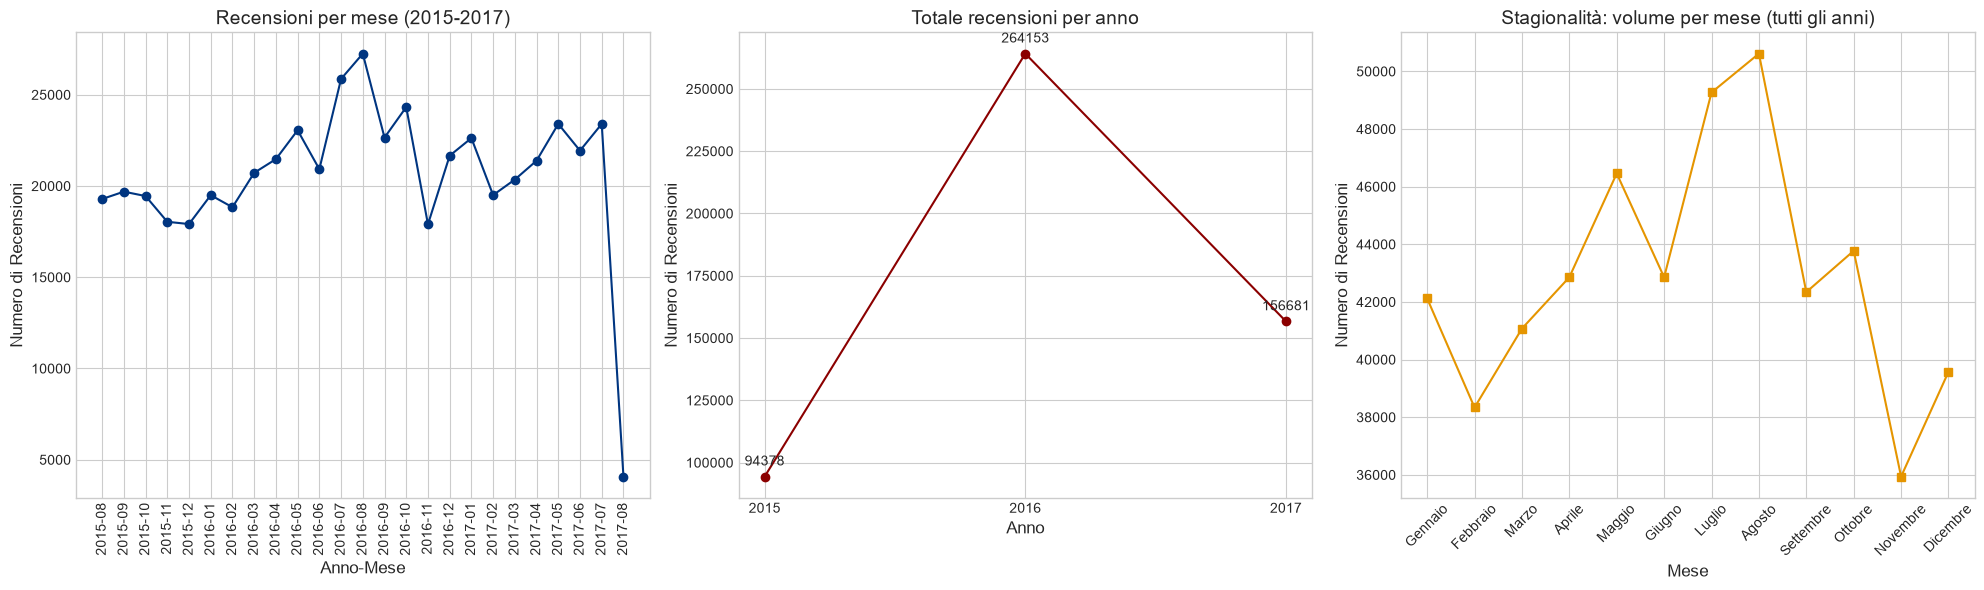

Salvato: True


In [12]:
# Mappa numero mese -> nome mese
nomi_mesi_map = {
    1: 'Gennaio', 2: 'Febbraio', 3: 'Marzo', 4: 'Aprile', 5: 'Maggio', 6: 'Giugno',
    7: 'Luglio', 8: 'Agosto', 9: 'Settembre', 10: 'Ottobre', 11: 'Novembre', 12: 'Dicembre'
}
ordine_mesi = list(nomi_mesi_map.values())

# Pannello 1: trend cronologico completo
# Costruzione di una etichetta "Anno-Mese" (es. "2015-08") 
# per avere sull'asse X ogni singolo mese in ordine temporale, dal primo all'ultimo.
# DataFrame 'conteggio_mensile' già calcolato al punto 4.4.2
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

conteggio_mensile['Anno_Mese'] = (
    conteggio_mensile['Review_Year'].astype(str) + "-" +
    conteggio_mensile['Review_Month'].astype(str).str.zfill(2)
)
ax1.plot(conteggio_mensile['Anno_Mese'], conteggio_mensile['Numero_Recensioni'],
          marker='o', linestyle='-', color='#003580')
ax1.set_title('Recensioni per mese (2015-2017)', fontsize=14)
ax1.set_xlabel('Anno-Mese', fontsize=12)
ax1.set_ylabel('Numero di Recensioni', fontsize=12)
ax1.tick_params(axis='x', rotation=90)

# Pannello 2: totale recensioni per anno
# "recensioni/anno": somma di tutte le recensioni di ciascun anno (2015, 2016, 2017) in un unico numero e si mettono a confronto.
totale_annuale = df.groupby('Review_Year').size()
ax2.plot(totale_annuale.index.astype(str), totale_annuale.values,
          marker='o', linestyle='-', color='#8B0000')
ax2.set_title('Totale recensioni per anno', fontsize=14)
ax2.set_xlabel('Anno', fontsize=12)
ax2.set_ylabel('Numero di Recensioni', fontsize=12)

# Numero esatto sopra ogni punto, per leggerlo senza dover stimare dall'asse Y
for x, y in zip(totale_annuale.index.astype(str), totale_annuale.values):
    ax2.annotate(str(y), (x, y), textcoords="offset points", xytext=(0, 8), ha='center')

# Pannello 3: stagionalità mensile
# recensioni per mese, sommando insieme tutti gli anni 
# (es. tutti gli agosto 2015+2016+2017 diventano un unico valore "Agosto"). 
# Si verifica se esistono mesi ricorrenti con più recensioni, indipendentemente dall'anno.
stagionalita = df.groupby('Review_Month').size()
stagionalita.index = stagionalita.index.map(nomi_mesi_map)
stagionalita = stagionalita.reindex(ordine_mesi)

ax3.plot(stagionalita.index, stagionalita.values, marker='s', linestyle='-', color='#E59500')
ax3.set_title('Stagionalità: volume per mese (tutti gli anni)', fontsize=14)
ax3.set_xlabel('Mese', fontsize=12)
ax3.set_ylabel('Numero di Recensioni', fontsize=12)
ax3.tick_params(axis='x', rotation=45)

# Sistemazione degli spazi tra i 3 pannelli e salvataggio dell'immagine completa
plt.tight_layout()
plt.savefig('charts/01_line_plot_recensioni_mese_e_anno.png', dpi=300, bbox_inches='tight')
plt.show()

# Verifica del salvataggio
print("Salvato:", os.path.exists('charts/01_line_plot_recensioni_mese_e_anno.png'))

####
4.5.2 Bar chart top 10 nazionalità per recensioni

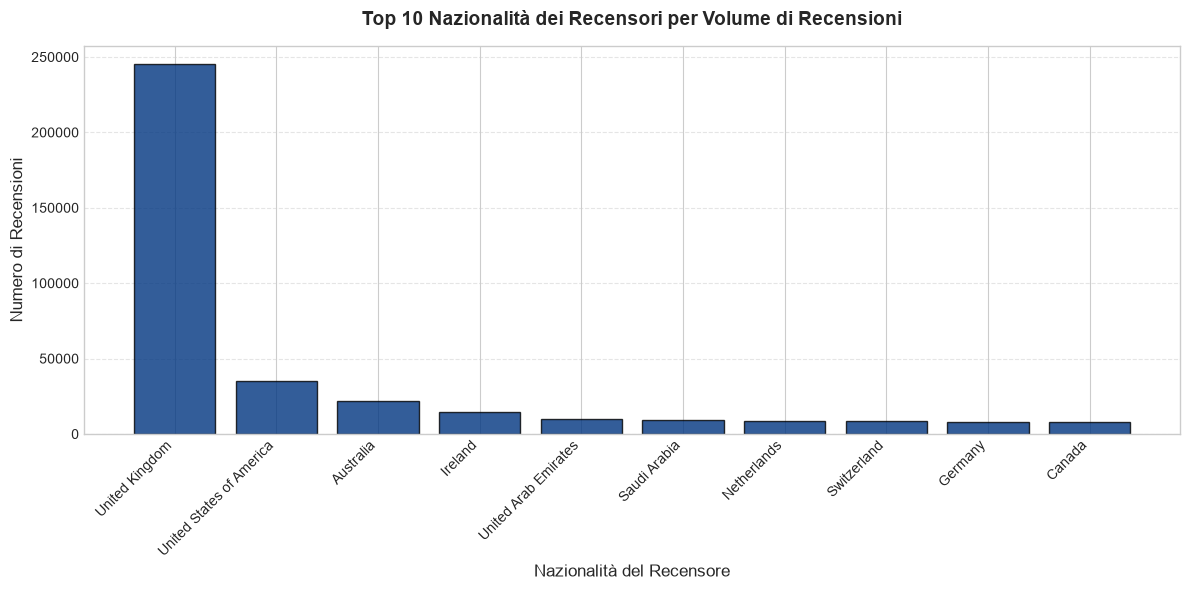

Salvato: True


In [13]:
# 1. Calcolo delle top 10 nazionalità per numero di recensioni
top_10_nat = df['Reviewer_Nationality'].value_counts().head(10)

# 2. Creazione della figura
plt.figure(figsize=(12, 6))
plt.bar(top_10_nat.index, top_10_nat.values, color='#003580', edgecolor='black', alpha=0.8)

# 3. Personalizzazione del grafico
plt.title('Top 10 Nazionalità dei Recensori per Volume di Recensioni', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Nazionalità del Recensore', fontsize=12)
plt.ylabel('Numero di Recensioni', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 4. Ottimizzazione del layout e salvataggio
plt.tight_layout()
plt.savefig('charts/02_bar_chart_top10_nazionalita.png', dpi=300, bbox_inches='tight')
plt.show()

# Verifica del salvataggio
print("Salvato:", os.path.exists('charts/02_bar_chart_top10_nazionalita.png'))

####
4.5.3 Bar chart top 10 città per numero recensioni

Nota: il dataset copre solo 6 città (non 10)

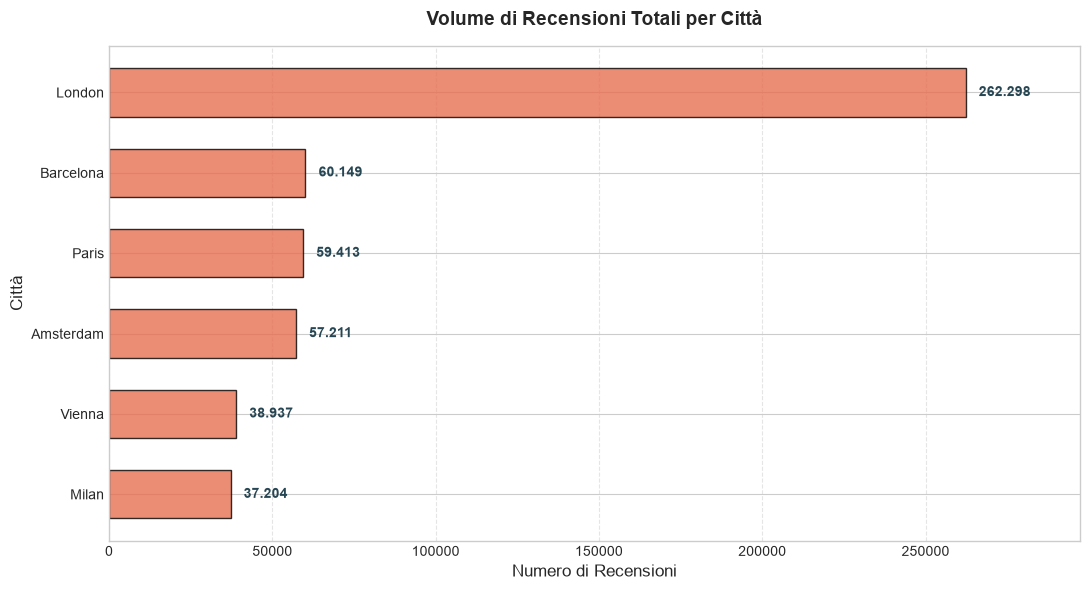

Salvato: True


In [14]:
# 1. Calcolo del volume delle recensioni per ogni città (ordinato dal valore più alto a quello più basso)
distribuzione_citta = df['City'].value_counts()

# 2. Creazione della figura
plt.figure(figsize=(11, 6))

# Barre orizzontali con l'ordine invertito [::-1] così la città con più recensioni (London) si posizionerà in alto
bars = plt.barh(distribuzione_citta.index[::-1], 
                distribuzione_citta.values[::-1], 
                color='#E76F51', edgecolor='black', height=0.6, alpha=0.8)

# 3. Personalizzazione del grafico
plt.title('Volume di Recensioni Totali per Città', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Numero di Recensioni', fontsize=12)
plt.ylabel('Città', fontsize=12)

# Aggiunta dei valori numerici esatti vicino a ciascuna barra per massima leggibilità
for bar in bars:
    xval = bar.get_width()
    plt.text(xval + 4000, bar.get_y() + bar.get_height()/2, 
             f"{int(xval):,}".replace(",", "."), 
             ha='left', va='center', fontsize=10, fontweight='bold', color='#264653')

# Estensione del limite dell'asse X per fare spazio al testo numerico di Londra senza tagliarlo
plt.xlim(0, distribuzione_citta.max() + 35000)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# 4. Ottimizzazione del layout e salvataggio
plt.tight_layout()
plt.savefig('charts/03_bar_chart_top6_citta_recensioni.png', dpi=300, bbox_inches='tight')
plt.show()

# Verifica del salvataggio
print("Salvato:", os.path.exists('charts/03_bar_chart_top6_citta_recensioni.png'))

####
4.5.4 Box plot distribuzione Reviewer Score per nazionalità top 3

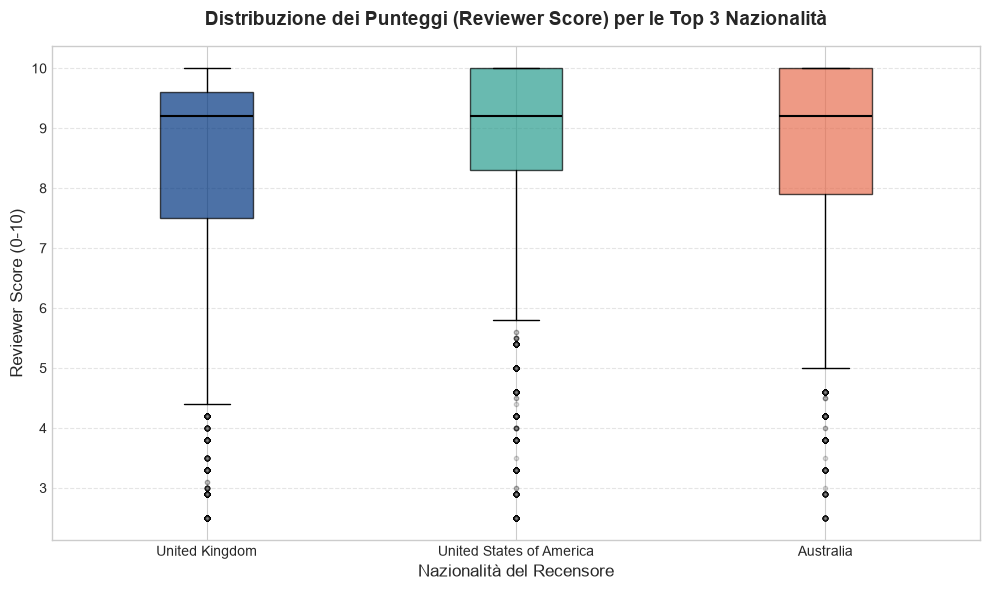

Salvato: True


In [15]:
# 1. Calcolo dinamico delle top 3 nazionalità per numero di recensioni
top_3_nazionalita = df['Reviewer_Nationality'].value_counts().head(3).index.tolist()

# 2. Filtraggio del dataset principale estraendo solo i record di queste tre nazionalità
df_top3 = df[df['Reviewer_Nationality'].isin(top_3_nazionalita)]

# 3. Creazione della figura
plt.figure(figsize=(10, 6))

# Creazione di una lista contenente le serie dei punteggi per ciascuna nazionalità
dati_box = [df_top3[df_top3['Reviewer_Nationality'] == nat]['Reviewer_Score'] for nat in top_3_nazionalita]

# Creazione del boxplot personalizzando la visualizzazione per massima leggibilità
box = plt.boxplot(dati_box, tick_labels=top_3_nazionalita, patch_artist=True,
                  medianprops=dict(color="black", linewidth=1.5),
                  flierprops=dict(marker='o', markerfacecolor='#888888', markersize=3, alpha=0.2))

# Applicazione dei colori della palette a ciascun box 
# (coerenti con i grafici precedenti)
colori_palette = ['#003580', '#2A9D8F', '#E76F51']
for patch, colore in zip(box['boxes'], colori_palette):
    patch.set_facecolor(colore)
    patch.set_alpha(0.7)
    patch.set_edgecolor('black')

# 4. Personalizzazione del grafico
plt.title('Distribuzione dei Punteggi (Reviewer Score) per le Top 3 Nazionalità', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Nazionalità del Recensore', fontsize=12)
plt.ylabel('Reviewer Score (0-10)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 5. Ottimizzazione del layout e salvataggio
plt.tight_layout()
plt.savefig('charts/04_box_plot_score_top3_nazionalita.png', dpi=300, bbox_inches='tight')
plt.show()

# Verifica del salvataggio
print("Salvato:", os.path.exists('charts/04_box_plot_score_top3_nazionalita.png'))

####
4.5.5 Histogram Review Length per categoria score

Valori unici in Score_Category: ['Basso (0-5)', 'Buono (7-9)', 'Medio (5-7)', 'Ottimo (9-10)']
Chiavi del dizionario colori: ['Basso (0-5)', 'Medio (5-7)', 'Buono (7-9)', 'Ottimo (9-10)']
Score_Category
Basso (0-5)       22232
Buono (7-9)      181668
Medio (5-7)       64485
Ottimo (9-10)    246827
Name: count, dtype: int64


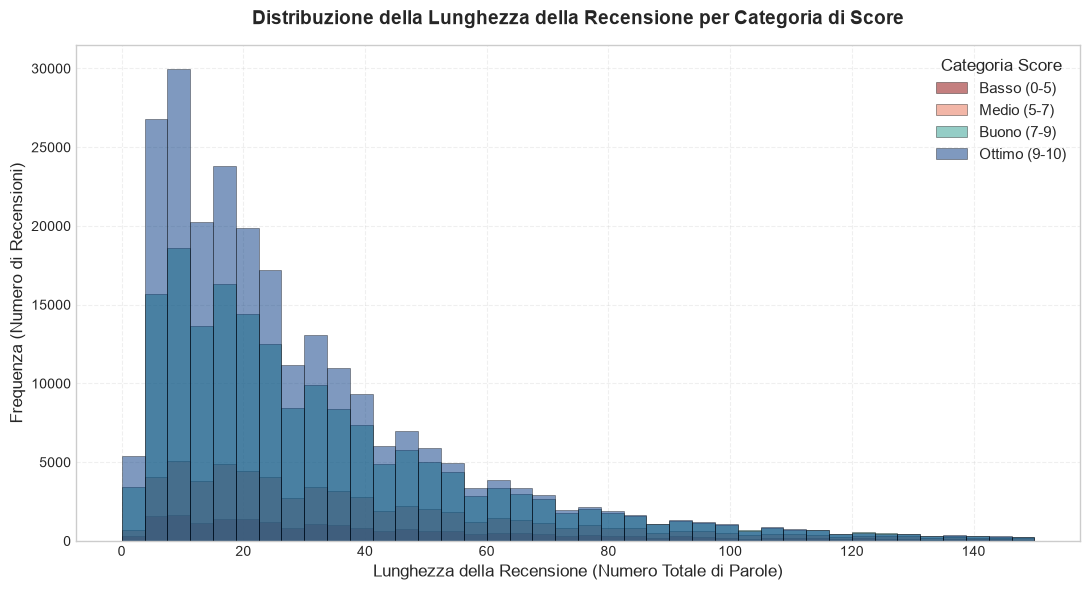

Salvato: True


In [16]:
# 1. Definizione dei colori e l'ordine esatto delle 4 categorie di score (coerenti con SQL)
colori = {
    'Basso (0-5)': '#8B0000',
    'Medio (5-7)': '#E76F51',
    'Buono (7-9)': '#2A9D8F',
    'Ottimo (9-10)': '#003580'
}

# Verifica: le categorie nel dataset devono coincidere con le chiavi del dizionario
print("Valori unici in Score_Category:", df['Score_Category'].unique().tolist())
print("Chiavi del dizionario colori:", list(colori.keys()))

# Aggiornamento
print(df['Score_Category'].value_counts().sort_index())

# 2. Creazione della figura
plt.figure(figsize=(11, 6))

for categoria in colori.keys():
    subset = df[df['Score_Category'] == categoria]['Total_Review_Length']
    plt.hist(subset, bins=40, range=(0, 150), alpha=0.5,
             color=colori[categoria], label=categoria,
             edgecolor='black', linewidth=0.5)

# 3. Personalizzazione del grafico
plt.title('Distribuzione della Lunghezza della Recensione per Categoria di Score', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Lunghezza della Recensione (Numero Totale di Parole)', fontsize=12)
plt.ylabel('Frequenza (Numero di Recensioni)', fontsize=12)
plt.legend(fontsize=11, title="Categoria Score", title_fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)

# 4. Ottimizzazione del layout e salvataggio
plt.tight_layout()
plt.savefig('charts/05_histogram_review_length_per_categoria_score.png', dpi=300, bbox_inches='tight')
plt.show()

# Verifica del salvataggio
print("Salvato:", os.path.exists('charts/05_histogram_review_length_per_categoria_score.png'))

####
4.5.6 Scatter plot Review Length vs Reviewer Score (colore per nazionalità)


Quando si hanno troppi dati (oltre 515.000 righe), fare un grafico a dispersione (scatter plot) con tutti i punti crea due problemi:

1. Rallentamenti: con centinaia di migliaia di punti, il rendering del grafico diventa lento e il file immagine risulta molto più pesante del necessario.
2. Grafico illeggibile (overplotting): i punti si sovrappongono tutti tra loro, creando un'unica grande macchia di colore che nasconde dove si concentrano davvero i dati.

La soluzione:<br>invece di usare tutti i dati, si prende un campione casuale più piccolo ma rappresentativo (5.000 recensioni). Per renderlo chiaro, si colorano solo i punti delle 3 nazionalità più frequenti (United Kingdom, United States of America, Australia) e si lasciano tutte le altre con un colore grigio neutro sullo sfondo.

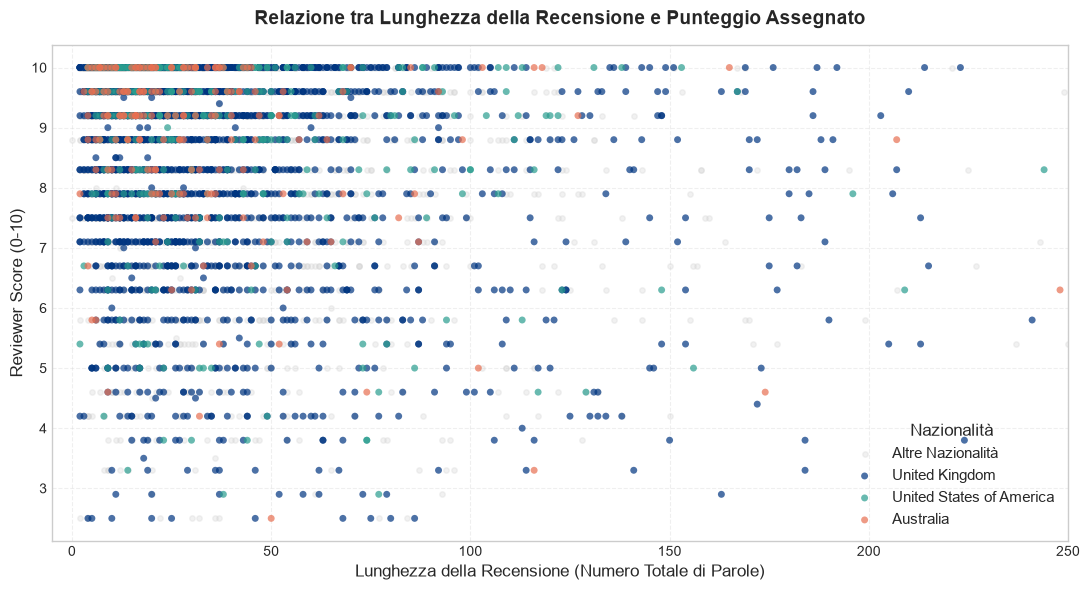

Salvato: True


In [17]:
# RIMOZIONE SPAZI BIANCHI: Pulizia della colonna da eventuali spazi extra all'inizio/fine stringa

# Aggiornamento

# --- CODICE STORICO (non più necessario, mantenuto per documentazione) ---
# Questa pulizia era stata aggiunta come soluzione tampone quando il Grafico 6
# falliva con KeyError ' United Kingdom ': il DATASET.csv dell'epoca conteneva
# spazi bianchi extra nei valori di Reviewer_Nationality.
# La pulizia è stata poi spostata alla fonte, nella fase di cleaning del
# notebook 01 (sezione 3.0), quindi il CSV arriva ora già pulito e questa
# riga non serve più.
#
# df['Reviewer_Nationality'] = df['Reviewer_Nationality'].astype(str).str.strip()

# 1. Estrazione di un campione casuale significativo per evitare l'overplotting
df_sample = df.sample(n=5000, random_state=42).copy()

# 2. Identificazione delle top 3 nazionalità e si raggruppa le altre come 'Altre'
top_3_naz = df['Reviewer_Nationality'].value_counts().head(3).index.tolist()
df_sample['Nationality_Group'] = df_sample['Reviewer_Nationality'].apply(lambda x: x if x in top_3_naz else 'Altre')

# 3. Palette di colori coerente con l'intero progetto
colori_scatter = {
    'United Kingdom': '#003580',
    'United States of America': '#2A9D8F',
    'Australia': '#E76F51',
    'Altre': '#D3D3D3'  # Grigio chiaro per lo sfondo neutro
}

# 4. Creazione della figura
plt.figure(figsize=(11, 6))

# Si traccia prima il gruppo 'Altre' (layer inferiore) con la lunghezza su X e lo score su Y
altre_mask = df_sample['Nationality_Group'] == 'Altre'
plt.scatter(df_sample[altre_mask]['Total_Review_Length'], df_sample[altre_mask]['Reviewer_Score'],
            alpha=0.3, color=colori_scatter['Altre'], label='Altre Nazionalità', s=15)

# Si traccia sopra le top 3 nazionalità (layer superiore)
for nat in top_3_naz:
    nat_mask = df_sample['Nationality_Group'] == nat
    plt.scatter(df_sample[nat_mask]['Total_Review_Length'], df_sample[nat_mask]['Reviewer_Score'],
                alpha=0.7, color=colori_scatter[nat], label=nat, s=25, edgecolor='none')

# 5. Personalizzazione del grafico e degli assi in base alla richiesta X vs Y
plt.title('Relazione tra Lunghezza della Recensione e Punteggio Assegnato', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Lunghezza della Recensione (Numero Totale di Parole)', fontsize=12)
plt.ylabel('Reviewer Score (0-10)', fontsize=12)
plt.legend(fontsize=11, title="Nazionalità", title_fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)

# Si limita l'asse X (lunghezza) per focalizzarsi sul corpo principale della distribuzione
plt.xlim(-5, 250)

# 6. Ottimizzazione del layout e salvataggio
plt.tight_layout()
plt.savefig('charts/06_scatter_plot_length_vs_score.png', dpi=300, bbox_inches='tight')
plt.show()

# Verifica del salvataggio
print("Salvato:", os.path.exists('charts/06_scatter_plot_length_vs_score.png'))

####
4.5.7 Bar chart score medio per top 10 città

Nel dataset sono presenti esattamente 6 città<br>
(Londra, Parigi, Amsterdam, Milano, Barcellona, Vienna)

Punteggi medi per città:
 City
Barcelona    8.554092
Vienna       8.545037
Amsterdam    8.456230
Paris        8.424395
Milan        8.346678
London       8.324130
Name: Reviewer_Score, dtype: float64


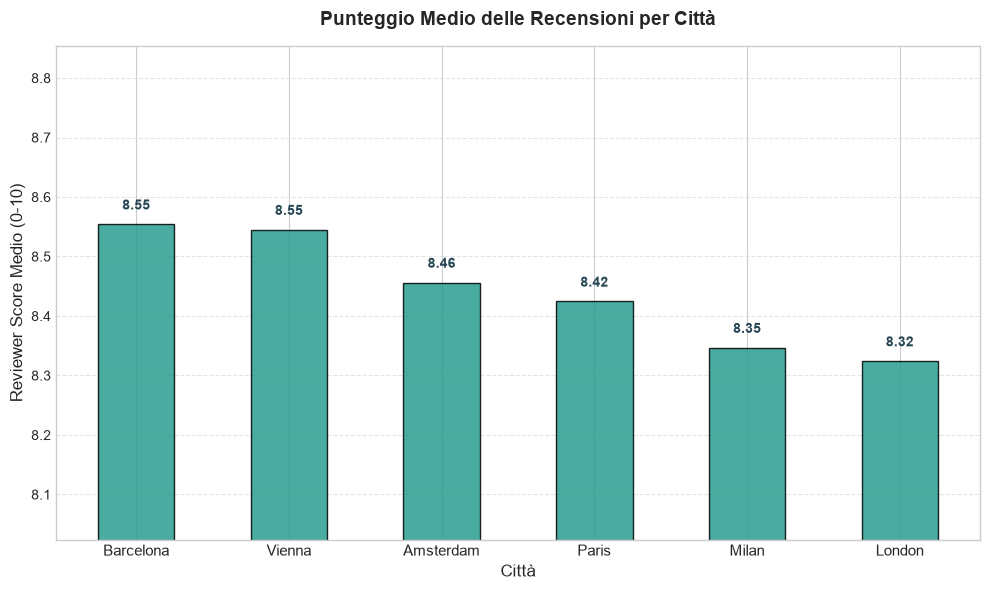

Salvato: True


In [18]:
# 1. Calcolo della media del Reviewer_Score raggruppata per città, ordinata dal punteggio più alto al più basso
medie_citta = df.groupby('City')['Reviewer_Score'].mean().sort_values(ascending=False)

# Verifica a schermo dei valori calcolati
print("Punteggi medi per città:\n", medie_citta)

# 2. Creazione della figura
plt.figure(figsize=(10, 6))
bars = plt.bar(medie_citta.index, medie_citta.values, color='#2A9D8F', edgecolor='black', width=0.5, alpha=0.85)

# 3. Personalizzazione del grafico
plt.title('Punteggio Medio delle Recensioni per Città', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Città', fontsize=12)
plt.ylabel('Reviewer Score Medio (0-10)', fontsize=12)
plt.xticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Aggiunta dei valori numerici esatti sopra ogni barra per una precisione immediata
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02,
             f"{yval:.2f}",
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='#264653')

# Zoom sull'asse Y con un margine proporzionale, per enfatizzare visivamente
# le differenze reali tra le città (circa 0.2 punti)
min_val = medie_citta.min()
max_val = medie_citta.max()
plt.ylim(max(0, min_val - 0.3), max_val + 0.3)

# 4. Ottimizzazione del layout e salvataggio
plt.tight_layout()
plt.savefig('charts/07_bar_chart_score_medio_citta.png', dpi=300, bbox_inches='tight')
plt.show()

# Verifica del salvataggio
print("Salvato:", os.path.exists('charts/07_bar_chart_score_medio_citta.png'))

####
4.5.8 Heatmap correlazioni numeriche<br>(score, word counts, days since
review)

Matrice di Correlazione:
                                    Reviewer_Score  Average_Score  \
Reviewer_Score                           1.000000       0.364175   
Average_Score                            0.364175       1.000000   
Review_Total_Negative_Word_Counts       -0.382552      -0.112351   
Review_Total_Positive_Word_Counts        0.220709       0.106639   
days_since_review                        0.002485      -0.014018   
Total_Review_Length                     -0.168362      -0.025997   

                                   Review_Total_Negative_Word_Counts  \
Reviewer_Score                                             -0.382552   
Average_Score                                              -0.112351   
Review_Total_Negative_Word_Counts                           1.000000   
Review_Total_Positive_Word_Counts                           0.119693   
days_since_review                                          -0.043217   
Total_Review_Length                                         0.830

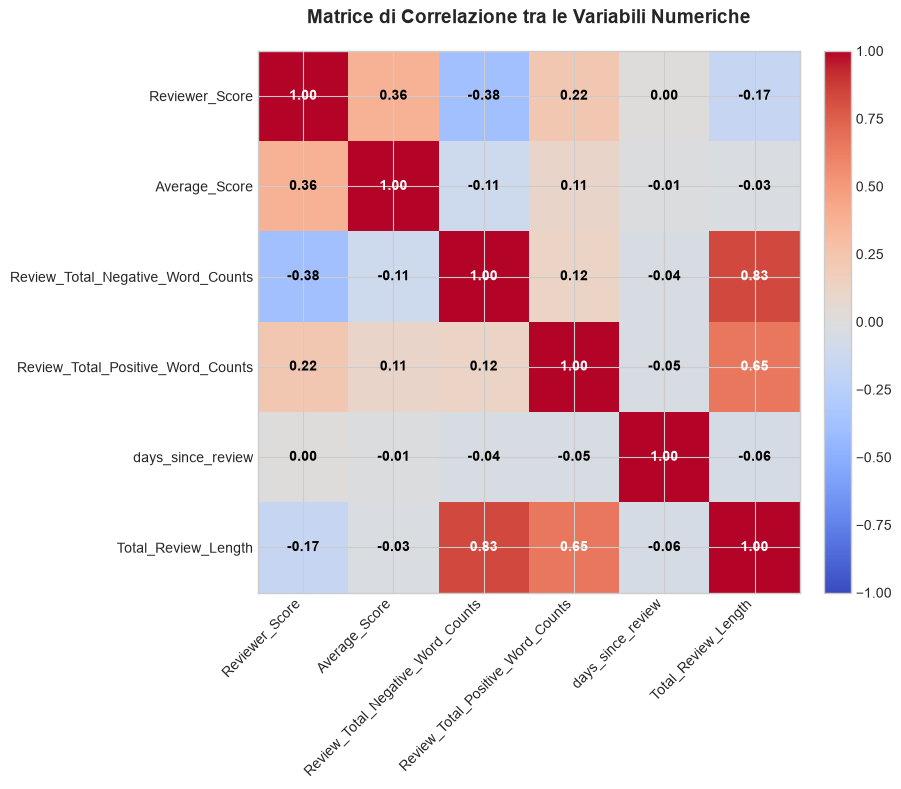

Salvato: True

Correlazione lunghezza recensione vs Reviewer_Score: -0.1684


In [19]:
# 1. Selezione delle colonne richieste esplicitamente dalle istruzioni (punto 4.5.8):
#    score, word counts (positivi e negativi), days since review, più la lunghezza totale
#    (per rispondere anche alla correlazione lunghezza vs score richiesta al punto 4.3.5)
colonne_numeriche = [
    'Reviewer_Score', 'Average_Score',
    'Review_Total_Negative_Word_Counts', 'Review_Total_Positive_Word_Counts',
    'days_since_review', 'Total_Review_Length'
]

# Calcolo della matrice di correlazione di Pearson
matrice_corr = df[colonne_numeriche].corr()
print("Matrice di Correlazione:\n", matrice_corr)

# 2. Creazione della figura (leggermente più larga per accomodare bene i nomi delle colonne)
fig, ax = plt.subplots(figsize=(9, 8))

# Si genera la heatmap con scala fissa -1/+1 e mappa 'coolwarm'
cax = ax.imshow(matrice_corr, cmap='coolwarm', vmin=-1, vmax=1)

# Aggiunta della barra laterale come legenda cromatica dell'intensità
cbar = fig.colorbar(cax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=10)

# 3. Personalizzazione degli assi (etichette)
ax.set_xticks(range(len(colonne_numeriche)))
ax.set_yticks(range(len(colonne_numeriche)))
ax.set_xticklabels(colonne_numeriche, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(colonne_numeriche, fontsize=10)

# 4. Annotazioni interne con contrasto dinamico del testo per massima leggibilità
for i in range(len(colonne_numeriche)):
    for j in range(len(colonne_numeriche)):
        valore = matrice_corr.iloc[i, j]
        colore_testo = 'white' if abs(valore) > 0.5 else 'black'
        ax.text(j, i, f"{valore:.2f}", ha='center', va='center',
                fontsize=10, fontweight='bold', color=colore_testo)

# 5. Titolo e rifinitura del layout
plt.title('Matrice di Correlazione tra le Variabili Numeriche', fontsize=14, pad=20, fontweight='bold')

# 6. Ottimizzazione del layout e salvataggio dell'immagine finale
plt.tight_layout()
plt.savefig('charts/08_heatmap_correlazione.png', dpi=300, bbox_inches='tight')
plt.show()

# Verifiche di controllo e output numerico per il report conclusivo
print("Salvato:", os.path.exists('charts/08_heatmap_correlazione.png'))
print("\nCorrelazione lunghezza recensione vs Reviewer_Score:", f"{matrice_corr.loc['Total_Review_Length', 'Reviewer_Score']:.4f}")